In [1]:
include("../src-fig/plotting.jl")
include("../src-fig/figures/video.jl")
include("../src-fig/figures/frontogenesis.jl")

ts_grow = [50, 72.5, 70, 67.5, 65, 65, 57.5];
ts_max = [80, 112.5, 127.5, 127.5, 127.5, 132.5, 132.5];
ts_decay = [100, 162.5, 175, 177.5, 192.5, 197.5, 200];

[ Info: Oceananigans will use 4 threads


In [11]:
# Some kind of fun background
fig = Figure(; size=(1000, 1000))
ax = Axis(fig[1, 1])
hidexdecorations!(ax)
hideydecorations!(ax)
begin
    run_id = ensemble.cooling_set.filenames[6]
    STRAINTENSOR = joinpath(scratchpath, run_id, "STRAINTENSOR.jld2")
    iterations, times = iterations_times(STRAINTENSOR)
    sp = simulation_parameters(STRAINTENSOR)
    n = 40
    #γ = get_field(STRAINTENSOR, "γb", iterations[n])
    #σ = get_field(STRAINTENSOR, "σ", iterations[n]) ./ sp.f
    #Fb = get_field(STRAINTENSOR, "Fb", iterations[n])
    ζ = get_field(STRAINTENSOR, "ζ", iterations[n])
    heatmap!(ax, ζ; colormap=:curl, colorrange=(-sp.f, sp.f))
end
save("figures/background.png", fig; px_per_unit=2)

1, tiny-mixing: t_max = 112.5 / f, t_growth = 72.5 / f, t_decay = 162.5 / f
2, low-mixing: t_max = 127.5 / f, t_growth = 70.0 / f, t_decay = 175.0 / f
3, medl-mixing: t_max = 127.5 / f, t_growth = 67.5 / f, t_decay = 177.5 / f
4, med-mixing: t_max = 127.5 / f, t_growth = 65.0 / f, t_decay = 192.5 / f
5, medh-mixing: t_max = 132.5 / f, t_growth = 65.0 / f, t_decay = 197.5 / f
6, high-mixing: t_max = 132.5 / f, t_growth = 57.5 / f, t_decay = 200.0 / f


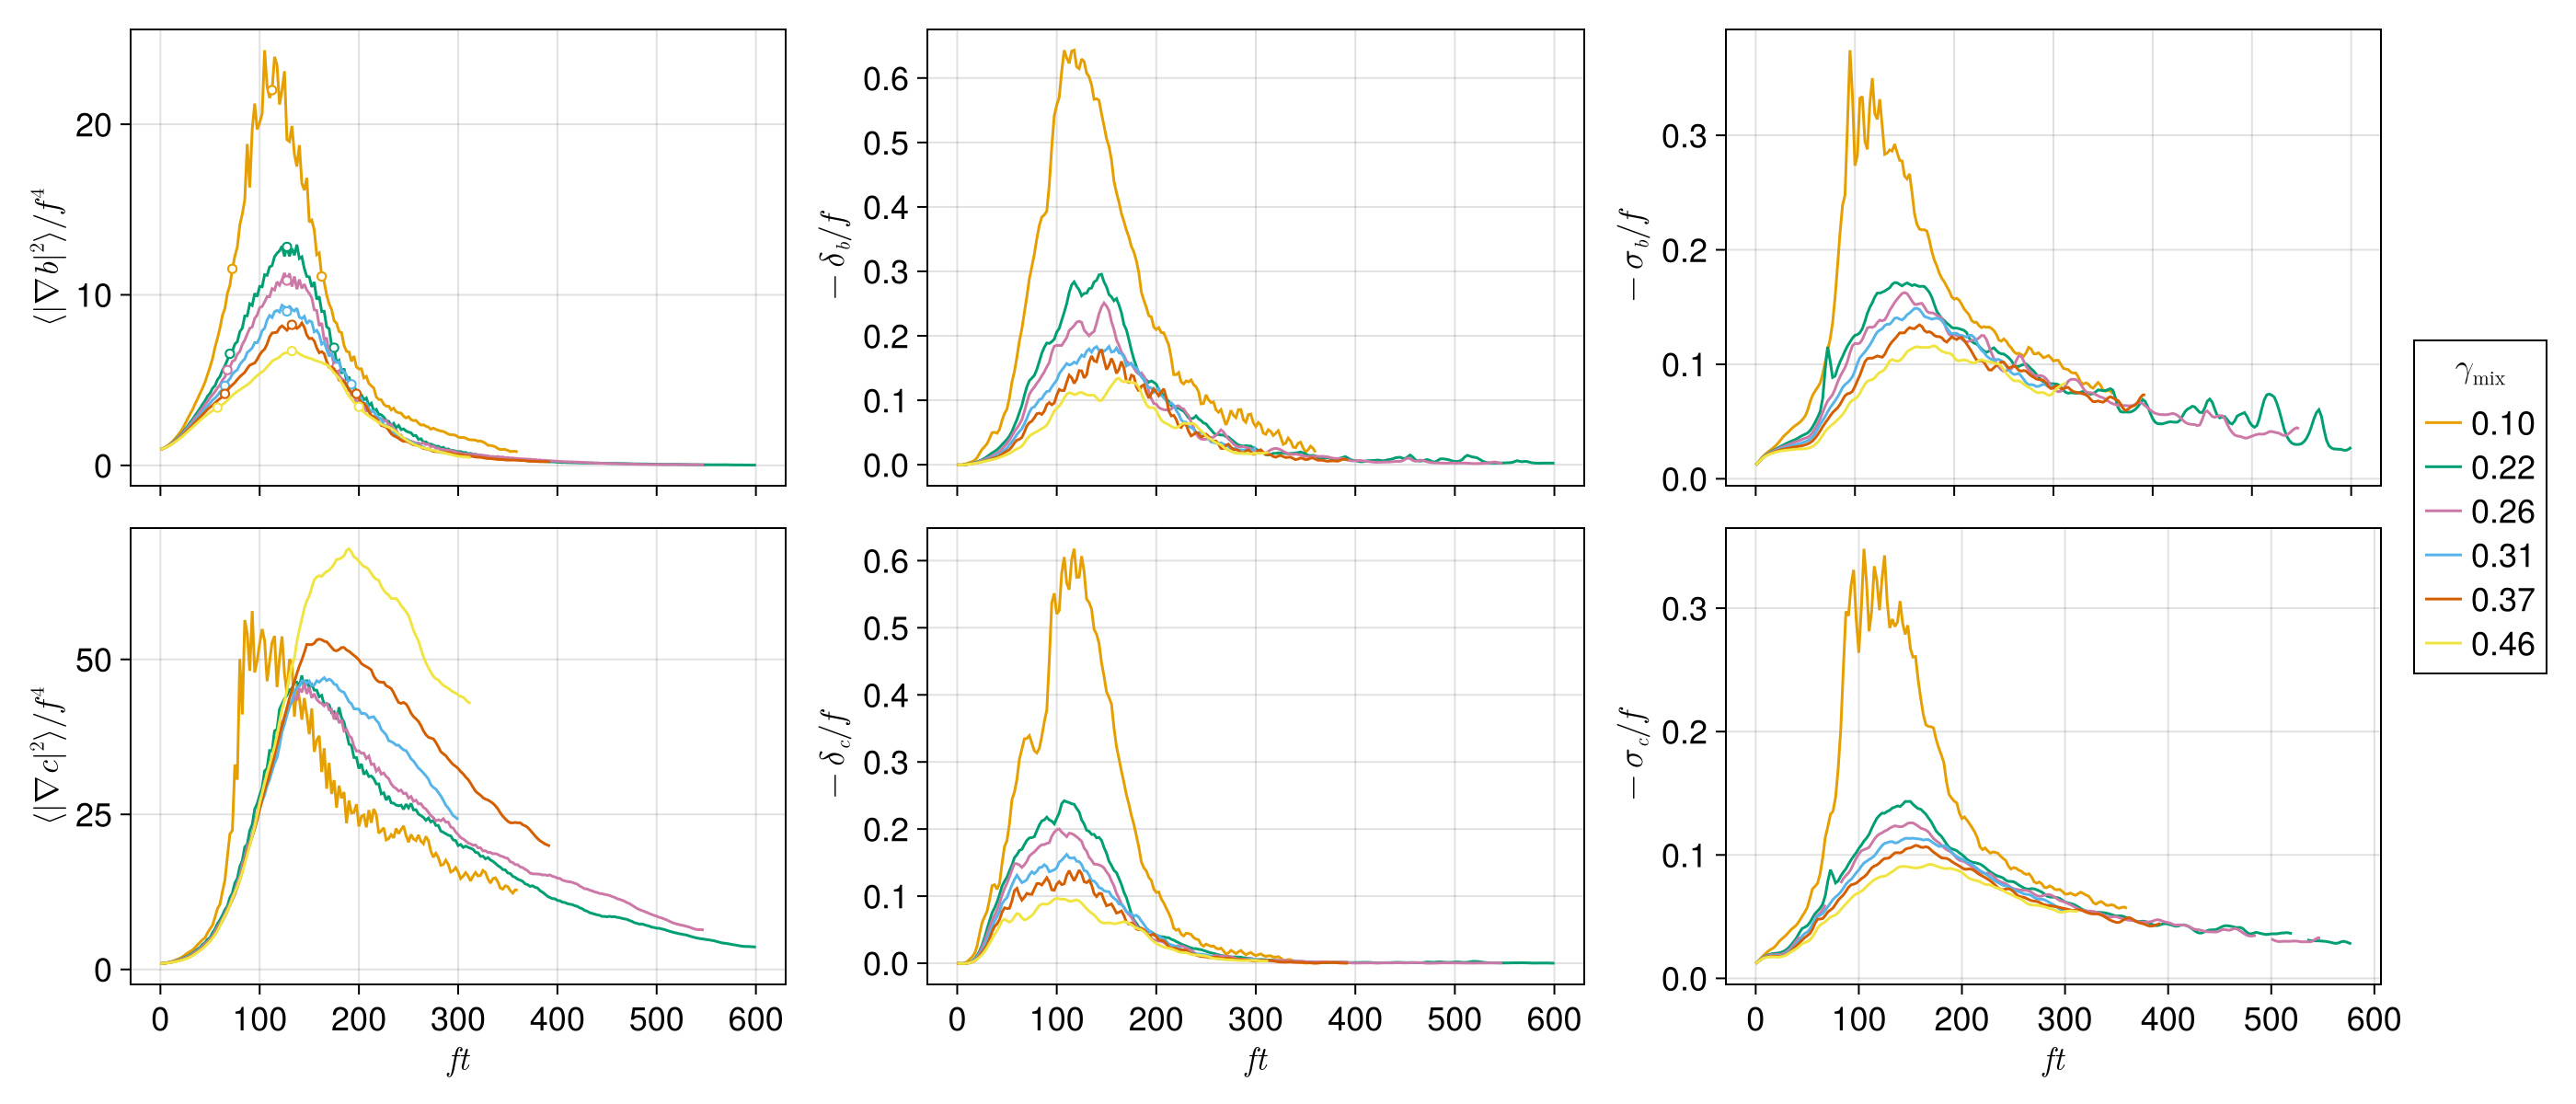

In [10]:
fig = frontogenesistimeseries(ensemble.cooling_set.filenames[2:7], Makie.wong_colors()[2:7])
save("figures/frontogenesis.png", fig; px_per_unit=2)
fig

In [13]:
# Invariants of the strain tensor at the max front strength
for n in 1:length(ensemble.cooling_set.filenames)
    run_id = ensemble.cooling_set.filenames[n]
    filename = "figures/gradient-$(run_id).png"
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    N = length(iterations)
    i = argmin(abs.(ts_max[n] / sp.f .- times))
    
    fig = gradient_video(run_id, [i], ""; fig_kw=(; size=(800, 400)))
    save(filename, fig; px_per_unit=4) 
end

# Growth time
for n in 1:length(ensemble.cooling_set.filenames)
    run_id = ensemble.cooling_set.filenames[n]
    filename = "figures/gradient-$(run_id)-grow.png"
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    N = length(iterations)
    i = argmin(abs.(ts_grow[n] / sp.f .- times))
    
    fig = gradient_video(run_id, [i], ""; fig_kw=(; size=(800, 400)))
    save(filename, fig; px_per_unit=4) 
end

# Decay time
for n in 1:length(ensemble.cooling_set.filenames)
    run_id = ensemble.cooling_set.filenames[n]
    filename = "figures/gradient-$(run_id)-decay.png"
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    N = length(iterations)
    i = argmin(abs.(ts_decay[n] / sp.f .- times))
    
    fig = gradient_video(run_id, [i], ""; fig_kw=(; size=(800, 400)))
    save(filename, fig; px_per_unit=4) 
end

In [14]:
for n in 1:length(ensemble.cooling_set.filenames)
    run_id = ensemble.cooling_set.filenames[n]
    filename = "figures/potential-$(run_id).png"
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    N = length(iterations)
    i = argmin(abs.(ts_max[n] / sp.f .- times))
    
    fig = potential_video(run_id, [i], ""; fig_kw=(; size=(800, 400)))
    save(filename, fig; px_per_unit=4)
end

for n in 1:length(ensemble.cooling_set.filenames)
    run_id = ensemble.cooling_set.filenames[n]
    filename = "figures/potential-$(run_id)-grow.png"
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    N = length(iterations)
    i = argmin(abs.(ts_grow[n] / sp.f .- times))
    
    fig = potential_video(run_id, [i], ""; fig_kw=(; size=(800, 400)))
    save(filename, fig; px_per_unit=4)
end

for n in 1:length(ensemble.cooling_set.filenames)
    run_id = ensemble.cooling_set.filenames[n]
    filename = "figures/potential-$(run_id)-decay.png"
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    N = length(iterations)
    i = argmin(abs.(ts_decay[n] / sp.f .- times))
    
    fig = potential_video(run_id, [i], ""; fig_kw=(; size=(800, 400)))
    save(filename, fig; px_per_unit=4)
end

In [3]:
for run_id in ensemble.cooling_set.filenames
    filename = "videos/gradient-$(run_id).mp4"
    isfile(filename) && continue
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    N = length(iterations)
    
    gradient_video(run_id, 1:N, filename; fig_kw=(; size=(800, 400)), record_kw=(; framerate=12))
end

354s / 354s (1097 / 1097)
185s / 185s (601 / 601)
249s / 249s (787 / 787)
192s / 192s (630 / 630)


In [2]:
for run_id in ensemble.cooling_set.filenames
    filename = "videos/potential-$(run_id).mp4"
    isfile(filename) && continue
    
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    iterations, times = iterations_times(SURFACE)
    N = length(iterations)
    
    potential_video(run_id, 1:N, filename; fig_kw=(; size=(800, 400)), record_kw=(; framerate=12))
end

1357s / 1357s (630 / 630)
